In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [9]:
df = pd.read_csv("Fact_Orders_Clean.csv")

df.head()

,Order_ID,Order_Date,Branch_ID,City,Area,Product_ID,Product,Category,Quantity,Unit_Price,...,Net_Sales,Cost,Profit,Customer_ID,Order_Year,Order_Month,Month_Name,Day_Name,Profit_Margin,Delivery_Performance
0,O00001,2025-04-13,B002,Lahore,DHA,P002,Chicken Burger,Burgers,1,450,...,450.0,234.0,216.0,C0188,2025,4,April,Sunday,0.48,Not Applicable
1,O00002,2025-12-15,B005,Faisalabad,D-Ground,P003,Beef Burger,Burgers,2,650,...,1170.0,608.4,561.6,C0120,2025,12,December,Monday,0.48,Not Applicable
2,O00003,2025-09-28,B001,Lahore,Johar Town,P006,Loaded Fries,Sides,2,350,...,665.0,279.3,385.7,C0242,2025,9,September,Sunday,0.58,Not Applicable
3,O00004,2025-04-17,B001,Lahore,Johar Town,P002,Chicken Burger,Burgers,1,450,...,450.0,234.0,216.0,C0319,2025,4,April,Thursday,0.48,Not Applicable
4,O00005,2025-03-13,B001,Lahore,Johar Town,P008,Cola,Beverages,2,120,...,204.0,61.2,142.8,C0072,2025,3,March,Thursday,0.70,Fast


In [10]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 1500
Columns: 29
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Order_ID              1500 non-null   object 
 1   Order_Date            1500 non-null   object 
 2   Branch_ID             1500 non-null   object 
 3   City                  1500 non-null   object 
 4   Area                  1500 non-null   object 
 5   Product_ID            1500 non-null   object 
 6   Product               1500 non-null   object 
 7   Category              1500 non-null   object 
 8   Quantity              1500 non-null   int64  
 9   Unit_Price            1500 non-null   int64  
 10  Discount_Pct          1500 non-null   float64
 11  Order_Type            1500 non-null   object 
 12  Payment_Method        1500 non-null   object 
 13  Delivery_Time_Min     1500 non-null   float64
 14  Order_Accuracy_Pct    1500 non-null   float64
 15

In [11]:
df.describe()

,Quantity,Unit_Price,Discount_Pct,Delivery_Time_Min,Order_Accuracy_Pct,Gross_Sales,Discount_Amount,Net_Sales,Cost,Profit,Order_Year,Order_Month,Profit_Margin
count,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.0,1500.000000,1500.000000
mean,1.775333,346.500000,0.03480,12.249800,0.936933,613.940000,21.025667,592.914333,271.128713,321.785620,2025.0,6.542000,0.576120
std,0.868732,159.335103,0.04572,16.583149,0.044346,437.101416,37.068008,423.595635,227.462559,202.540571,0.0,3.426377,0.082255
min,1.000000,120.000000,0.00000,0.000000,0.750000,120.000000,0.000000,102.000000,30.600000,71.400000,2025.0,1.000000,0.480000
25%,1.000000,220.000000,0.00000,0.000000,0.910000,300.000000,0.000000,300.000000,113.400000,175.000000,2025.0,4.000000,0.480000
50%,2.000000,350.000000,0.00000,0.000000,0.940000,450.000000,0.000000,450.000000,192.000000,252.000000,2025.0,6.000000,0.580000
75%,2.000000,450.000000,0.05000,29.425000,0.970000,800.000000,27.500000,760.000000,345.600000,416.000000,2025.0,10.000000,0.650000
max,4.000000,650.000000,0.15000,54.900000,1.000000,2600.000000,292.500000,2600.000000,1352.000000,1248.000000,2025.0,12.000000,0.700000


In [12]:
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Order IDs:", df["Order_ID"].duplicated().sum())

Total missing values: 938
Duplicate rows: 0
Duplicate Order IDs: 0


In [13]:
branch_sales = (
    df.groupby("City")["Net_Sales"]
      .sum()
      .sort_values(ascending=False)
)

branch_sales

,Net_Sales
City,
Lahore,466219.5
Islamabad,172601.0
Rawalpindi,158460.0
Faisalabad,92091.0


In [14]:
product_sales = (
    df.groupby("Product")["Net_Sales"]
      .sum()
      .sort_values(ascending=False)
)

product_sales

,Net_Sales
Product,
Beef Burger,162142.5
Zinger Burger,150755.0
Chicken Burger,107887.5
Loaded Fries,100310.0
Chicken Wrap,97500.0
Chicken Nuggets,75885.0
Mint Margarita,63212.5
Fries,53361.0
Ice Cream,44244.0


In [15]:
monthly_sales = (
    df.groupby(["Order_Year", "Order_Month", "Month_Name"])["Net_Sales"]
      .sum()
      .reset_index()
      .sort_values(["Order_Year", "Order_Month"])
)

monthly_sales

,Order_Year,Order_Month,Month_Name,Net_Sales
0,2025,1,January,77182.5
1,2025,2,February,73318.5
2,2025,3,March,63736.0
3,2025,4,April,80836.5
4,2025,5,May,86852.0
5,2025,6,June,80796.5
6,2025,7,July,61490.0
7,2025,8,August,84178.0
8,2025,9,September,68803.5
9,2025,10,October,75945.5


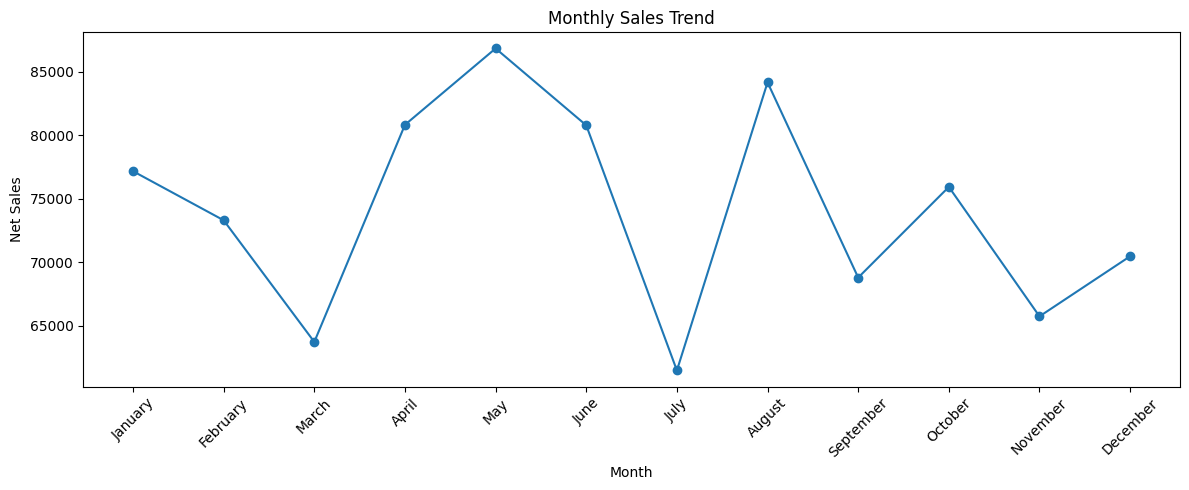

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["Month_Name"],
    monthly_sales["Net_Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Net Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

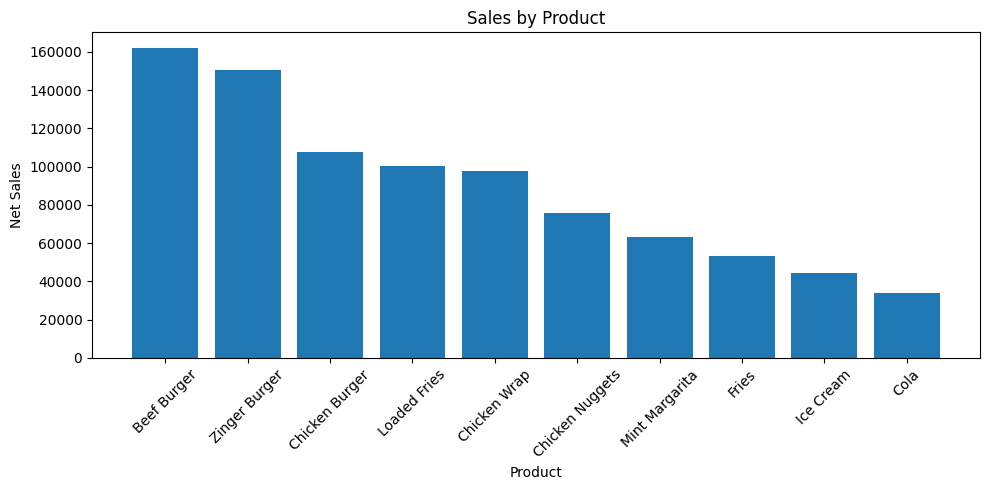

In [17]:
plt.figure(figsize=(10, 5))

plt.bar(
    product_sales.index,
    product_sales.values
)

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Net Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
correlation = df[
    ["Quantity", "Unit_Price", "Discount_Pct",
     "Delivery_Time_Min", "Order_Accuracy_Pct",
     "Net_Sales", "Profit"]
].corr()

correlation

,Quantity,Unit_Price,Discount_Pct,Delivery_Time_Min,Order_Accuracy_Pct,Net_Sales,Profit
Quantity,1.000000,-0.008769,-0.023890,-0.023089,0.018295,0.690011,0.781661
Unit_Price,-0.008769,1.000000,-0.025348,0.031089,0.028173,0.644039,0.541600
Discount_Pct,-0.023890,-0.025348,1.000000,-0.007505,0.018287,-0.082302,-0.096168
Delivery_Time_Min,-0.023089,0.031089,-0.007505,1.000000,-0.009168,0.010116,0.009098
Order_Accuracy_Pct,0.018295,0.028173,0.018287,-0.009168,1.000000,0.025442,0.024666
Net_Sales,0.690011,0.644039,-0.082302,0.010116,0.025442,1.000000,0.983252
Profit,0.781661,0.541600,-0.096168,0.009098,0.024666,0.983252,1.000000


In [19]:
delivery_sales = df.loc[
    df["Order_Type"] == "Delivery",
    "Net_Sales"
]

non_delivery_sales = df.loc[
    df["Order_Type"] != "Delivery",
    "Net_Sales"
]

t_stat, p_value = stats.ttest_ind(
    delivery_sales,
    non_delivery_sales,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.10428964490180989
P-value: 0.9169580536456626


In [20]:
if p_value < 0.05:
    print("The difference is statistically significant at the 5% level.")
else:
    print("The difference is not statistically significant at the 5% level.")

The difference is not statistically significant at the 5% level.


In [21]:
median_sales = df["Net_Sales"].median()

df["Order_Value_Segment"] = np.where(
    df["Net_Sales"] >= median_sales,
    "High Value",
    "Standard"
)

df[["Order_ID", "Net_Sales", "Order_Value_Segment"]].head()

,Order_ID,Net_Sales,Order_Value_Segment
0,O00001,450.0,High Value
1,O00002,1170.0,High Value
2,O00003,665.0,High Value
3,O00004,450.0,High Value
4,O00005,204.0,Standard


In [22]:
df["Order_Value_Segment"].value_counts()

,count
Order_Value_Segment,
High Value,785
Standard,715


In [23]:
print("Total Sales:", df["Net_Sales"].sum())
print("Total Profit:", df["Profit"].sum())
print("Average Order Value:", df["Net_Sales"].mean())

print("\nTop City by Sales:")
print(branch_sales.idxmax(), "=", branch_sales.max())

print("\nTop Product by Sales:")
print(product_sales.idxmax(), "=", product_sales.max())

print("\nAverage Delivery Time:")
print(
    df.loc[df["Order_Type"] == "Delivery", "Delivery_Time_Min"].mean()
)

Total Sales: 889371.5
Total Profit: 482678.43
Average Order Value: 592.9143333333334

Top City by Sales:
Lahore = 466219.5

Top Product by Sales:
Beef Burger = 162142.5

Average Delivery Time:
32.69519572953736


In [ ]:
# df.to_csv(
#     "QSR_Master_Project_Analytical_Dataset.csv",
#     index=False
# )

# print("Analytical dataset saved successfully.")

Analytical dataset saved successfully.


In [ ]:
# from google.colab import files

# files.download("QSR_Master_Project_Analytical_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>